# Code

## Configuration & General

### Imports

In [153]:
from sklearn import set_config
set_config(transform_output="pandas")

import os
import pandas as pd
import numpy as np
import torch
import joblib
import wandb
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, Dataset, DataLoader

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import drive

# --- CONFIGURATION & GLOBALS ---
drive.mount('content/')
wandb.login()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.style.use("ggplot")

BASE_DIR = "content/MyDrive/Colab Notebooks/GP Datasets/"
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

MAIN_CSV_FILE = "25_countries_main.csv"
MAIN_CSV_PATH = os.path.join(BASE_DIR, MAIN_CSV_FILE)

Drive already mounted at content/; to attempt to forcibly remount, call drive.mount("content/", force_remount=True).


### Preprocessing & Feature Engineering Pipeline

In [154]:
# @title
class FeatureEngineerMixin(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()

        X_copy['date'] = pd.to_datetime(X_copy['date'])

        X_copy['day_of_week'] = X_copy['date'].dt.dayofweek
        X_copy['quarter'] = X_copy['date'].dt.quarter

        # Add Cyclic Encoding Transformations for dates and seasons.
        X_copy['month_sin'] = np.sin(2 * np.pi * X_copy['month'] / 12)
        X_copy['month_cos'] = np.cos(2 * np.pi * X_copy['month'] / 12)
        X_copy['week_sin'] = np.sin(2 * np.pi * X_copy['week'] / 52)
        X_copy['week_cos'] = np.cos(2 * np.pi * X_copy['week'] / 52)

        # A. Temporal Lags (The "Incubation Period")
        # We look back 1 week for pollution and temprature because diseases aren't instant.
        X_copy['pm25_ugm3_lag_1w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(1)
        X_copy['pm25_ugm3_lag_2w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(2)
        X_copy['pm25_ugm3_lag_4w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(4)

        X_copy['temp_lag_1w'] = X_copy.groupby('country_code')['temperature_celsius'].shift(1)
        X_copy['temp_lag_2w'] = X_copy.groupby('country_code')['temperature_celsius'].shift(2)

        # B. Rolling Averages (The "Chronic Exposure")
        # B1. We calculate the average temperature of the last 4 weeks.
        X_copy['temp_2w_avg'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
        )

        # B2. Rolling standard deviation (volatility)
        X_copy['temp_2w_volatility'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=2, min_periods=1).std())
        )

        X_copy['temp_4w_volatility'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=4, min_periods=1).std())
        )

        # C. Mathematical Transformations (Non-Linearity)
        # Temperature usually has a U-shaped effect on health (bad if too hot OR too cold)
        X_copy['temp_squared'] = X_copy['temperature_celsius'] ** 2

        # Log-Transform Target Variables
        # We do NOT scale this later.
        # X_copy['food_security_index_log'] = np.log1p(X_copy['food_security_index'])


        # D. Scientific Logic: The human body adapts to gradual change.
        # Sudden spikes (Thermal Shock) cause heart attacks and asthma attacks.
        # D1. We calculate: (Current Week Value) - (Last Week Value)
        X_copy['temp_change_rate'] = X_copy.groupby('country_code')['temperature_celsius'].diff()
        X_copy['pm25_change_rate'] = X_copy.groupby('country_code')['pm25_ugm3'].diff()
        X_copy['precip_change_rate'] = X_copy.groupby('country_code')['precipitation_mm'].diff()

        # E. Calculate Spatial Lag for Respiratory Disease
        # We take the average disease rate of the 5 neighbors (excluding the country itself)
        coords = X_copy[['latitude' , 'longitude']].values

        nbrs = NearestNeighbors(n_neighbors=5 , algorithm='ball_tree').fit(coords)
        distances , indices = nbrs.kneighbors(coords)

        neighbor_idx = indices[: , 1:] # Drop the first one (itself)

        X_copy['spatial_lag_pm25'] = X_copy['pm25_ugm3'].values[neighbor_idx].mean(axis=1)
        X_copy['spatial_lag_temp'] = X_copy['temperature_celsius'].values[neighbor_idx].mean(axis=1)
        X_copy['spatial_lag_temp_anomaly'] = X_copy['temp_anomaly_celsius'].values[neighbor_idx].mean(axis=1)

        # F. The "Photochemical Smog" Effect
        # Scientific Logic: High heat catalyzes chemical reactions in pollutants (like Ozone/PM2.5), making them more toxic to the lungs.
        X_copy['pm25_temp_interaction'] = X_copy['pm25_ugm3'] * X_copy['temperature_celsius']
        X_copy['temp_precip_interaction'] = X_copy['temperature_celsius'] * X_copy['precipitation_mm']
        X_copy['pm25_precip_interaction'] = X_copy['pm25_ugm3'] * X_copy['precipitation_mm']

        # G. Hemisphere Indicators
        X_copy['is_northern'] = (X_copy['latitude'] > 0).astype(int)
        X_copy['is_tropical'] = (X_copy['latitude'].abs() < 23.5).astype(int)
        X_copy['distance_to_equator'] = X_copy['latitude'].abs()


        # I. The "Vulnerability" Effect
        # Scientific Logic: High pollution is manageable if Healthcare Access is high.
        # It becomes fatal if Healthcare is low.
        # We add a small epsilon (1e-6) to avoid division by zero.

        X_copy['pollution_vulnerability'] = X_copy['pm25_ugm3'] / (X_copy['healthcare_access_index'] + 1e-6)
        X_copy.fillna(X_copy.mean(numeric_only=True), inplace=True)

        self.feature_names_ = X_copy.columns.tolist()

        return X_copy

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_
        return self.feature_names_

In [155]:
# @title
class CountryIQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, country_col='country_id', multiplier=1.5):
        self.country_col = country_col
        self.multiplier = multiplier

    def fit(self, X, y=None):
        self.feature_names_ = X.columns.tolist()
        self.bounds_ = {}

        for country in X[self.country_col].unique():
            mask = X[self.country_col] == country
            country_data = X.loc[mask, self.feature_names_]

            self.bounds_[country] = {}

            for col in self.feature_names_:
                if col == self.country_col: continue

                series = country_data[col].dropna()

                if len(series) < 10:
                    self.bounds_[country][col] = (series.min(), series.max())
                    continue

                Q1 = series.quantile(0.25)
                Q3 = series.quantile(0.75)
                IQR = Q3 - Q1

                if IQR == 0:
                    self.bounds_[country][col] = (series.min(), series.max())
                    continue

                lower = Q1 - self.multiplier * IQR
                upper = Q3 + self.multiplier * IQR
                self.bounds_[country][col] = (lower, upper)

        return self

    def transform(self, X):
        if not hasattr(self, 'bounds_'):
            raise ValueError("Capper has not been fitted yet. Call fit() first.")

        _X = X.copy()

        for country in _X[self.country_col].unique():
            mask = _X[self.country_col] == country

            if country not in self.bounds_:
                continue

            for col in self.feature_names_:
                if col == self.country_col: continue

                lower, upper = self.bounds_[country][col]
                _X.loc[mask, col] = _X.loc[mask, col].clip(lower=lower, upper=upper)

        return _X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_
        return input_features

In [156]:
# @title
class SelectiveStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_cols=None, drop_excluded=False):
        self.exclude_cols = exclude_cols or []
        self.drop_excluded = drop_excluded

    def fit(self, X, y=None):
        X = X.copy()

        self.scale_cols_ = [c for c in X.columns if c not in self.exclude_cols]

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.scale_cols_])

        self.feature_names_in_ = X.columns.tolist()
        self.feature_names_out_ = self.scale_cols_ if self.drop_excluded else self.feature_names_in_

        return self

    def transform(self, X):
        X_copy = X.copy()

        X_copy[self.scale_cols_] = X_copy[self.scale_cols_].astype("float64")
        X_copy.loc[:, self.scale_cols_] = self.scaler_.transform(X_copy[self.scale_cols_])

        if self.drop_excluded:
            X_copy = X_copy[self.scale_cols_]

        return X_copy

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)

In [157]:
countries_ids = joblib.load(os.path.join(MODELS_DIR, "country_to_idx.joblib"))
ids_countries = joblib.load(os.path.join(MODELS_DIR, "idx_to_country.joblib"))
pipeline = joblib.load(os.path.join(MODELS_DIR, "feature_pipeline.joblib"))

### Loading data

In [158]:
data_df = pd.read_csv(MAIN_CSV_PATH, parse_dates=['date'])

# countries_ids = {"Vietnam": 0}
# ids_countries = {0: "Vietnam"}
# data_df = data_df[data_df['country_name'] == "Vietnam"]

data_df['country_id'] = data_df['country_name'].map(countries_ids)

data_df.shape

(14100, 33)

## Checkpoint Saver

In [256]:
# @title
import pickle
import copy
import glob

class CheckpointSaver:
    def __init__(self, dirpath="./checkpoints", decreasing=True, save_model=True):
        self.dirpath = dirpath
        os.makedirs(dirpath, exist_ok=True)
        self.decreasing = decreasing
        self.save_model = save_model

        # Track the best metric
        self.best_metric = float('inf') if decreasing else float('-inf')

        # We store the best checkpoint in RAM (CPU).
        self.best_checkpoint_payload = None
        self.best_epoch = -1
        self.best_fold = -1
        self.run_id = None

    def update(self, model, fold, epoch, metric, run_id):
        """Checks if current model is best. If yes, caches it to RAM."""

        is_best = (metric < self.best_metric) if self.decreasing else (metric > self.best_metric)

        if not is_best:
            return False

        self.best_metric = metric
        self.best_epoch = epoch
        self.best_fold = fold
        self.run_id = run_id

        self.best_checkpoint_payload = {
            "epoch": epoch,
            "metric": metric,
            "model_state_dict": {k: v.cpu().clone() for k, v in model.state_dict().items()}
        }

        print(f"-> New Best Model found at Epoch {epoch} | Metric={metric:.4f}")
        return True

    @staticmethod
    def load_artifact_model(run_id, model_instance, project="sehetna/sehetna-main"):
        api = wandb.Api()
        artifact_path = f"{project}/{run_id}"

        try:
            artifact = api.artifact(artifact_path)
        except Exception as e:
            print(f"Error: Could not find artifact at {artifact_path}: {e}")
            return None

        print("-> Downloading artifact...")
        artifact_dir = artifact.download()

        pkl_files = glob.glob(os.path.join(artifact_dir, "*.pkl"))
        if not pkl_files:
            print("Error: No .pkl file found in the artifact.")
            return None

        model_pkl = pkl_files[0]
        print(f"-> Found checkpoint: {os.path.basename(model_pkl)}")

        with open(model_pkl, "rb") as f:
            checkpoint = pickle.load(f)

        state_dict = checkpoint.get("model_state_dict", checkpoint)

        try:
            model_instance.load_state_dict(state_dict)
            print("-> Weights successfully loaded into model.")
        except RuntimeError as e:
            print(f"-> Shape Mismatch! Are you loading Transformer weights into an MLP?")
            print(f"Error: {e}")

            # Debug info
            print("\nExpected keys (first 5):")
            for i, key in enumerate(list(model_instance.state_dict().keys())[:5]):
                print(f"  {key}")

            print("\nCheckpoint keys (first 5):")
            for i, key in enumerate(list(state_dict.keys())[:5]):
                print(f"  {key}")

            return None

        return model_instance

    def __call__(self):
        """Call this ONCE at the very end of training."""
        if not self.save_model or self.best_checkpoint_payload is None:
            print("No model to save (or save_model=False).")
            return

        name = f"{self.run_id}-fold-{self.best_fold}-best-epoch-{self.best_epoch}.pkl"
        best_pkl = os.path.join(self.dirpath, name)

        description = f"Best Model: Fold {self.best_fold} | Epoch {self.best_epoch} | Metric={self.best_metric:.4f}"
        print(f"-> Saving to Disk: {name} ...")

        # Save to Disk
        with open(best_pkl, "wb") as f:
            pickle.dump(self.best_checkpoint_payload, f)

        # Upload to WandB
        if wandb.run is not None:
            print(f"-> Uploading to WandB...")
            artifact = wandb.Artifact(name=f"model-{self.run_id}", type="model", description=description)
            artifact.add_file(best_pkl)
            wandb.log_artifact(artifact)
            print("-> Upload Complete.")

## Feature Selection

In [160]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import MultiTaskElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

targets = ['respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions']
HELPER_COLS = ['record_id', 'country_code', 'country_name', 'region', 'income_level', 'date', 'year', 'week']

MISSING_RATIO_THRESHOLD = 0.3
CORR_THRESHOLD = 0.95
ELASTICNET_L1_RATIOS = [0.2, 0.5, 0.8]

RANDOM_STATE = 42

df = data_df.copy()

X = df.drop(columns=targets)
y = df[targets]

X_helpers = X[HELPER_COLS]
X_num = X.drop(columns=HELPER_COLS)

In [161]:
# ============================================================
# 1. SAFE PRE-FILTERING
# ============================================================

# ---- 1.1 Missing Value Filter
missing_ratio = X_num.isna().mean()
keep_missing = missing_ratio[missing_ratio <= MISSING_RATIO_THRESHOLD].index
X_num = X_num[keep_missing]

# ---- 1.2 Near-Zero Variance Filter
vt = VarianceThreshold(threshold=1e-4)
X_vt = vt.fit_transform(X_num)
vt_features = X_num.columns[vt.get_support()]
X_num = pd.DataFrame(X_vt, columns=vt_features, index=X_num.index)

# ---- 1.3 Extreme Correlation Filter
corr_matrix = X_num.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
X_num = X_num.drop(columns=to_drop_corr)

print(f"After pre-filtering: {X_num.shape[1]} features")

After pre-filtering: 17 features


In [162]:
# ============================================================
# 2. SCALING
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

In [163]:
# ============================================================
# 3. MULTI-TASK ELASTIC NET (CORE STEP)
# ============================================================

enet = MultiTaskElasticNetCV(l1_ratio=ELASTICNET_L1_RATIOS, cv=TimeSeriesSplit(n_splits=5), random_state=RANDOM_STATE, max_iter=10000, n_jobs=-1)

enet.fit(X_scaled, y.values)

# ---- Coefficient aggregation across targets
coef_matrix = enet.coef_          # shape: (n_targets, n_features)
coef_norm = np.linalg.norm(coef_matrix, axis=0)

coef_df = (
    pd.DataFrame({'feature': X_num.columns, 'coef_l2_norm': coef_norm})
    .sort_values('coef_l2_norm', ascending=False)
    .reset_index(drop=True)
)

# ---- Threshold: non-zero + percentage
NON_ZERO_THRESHOLD = np.percentile(coef_norm[coef_norm > 0], 15)

selected_elasticnet = coef_df[coef_df['coef_l2_norm'] > NON_ZERO_THRESHOLD]['feature'].tolist()

print(f"ElasticNet selected {len(selected_elasticnet)} features")

ElasticNet selected 12 features


In [165]:
# ============================================================
# 4. PERMUTATION IMPORTANCE (VALIDATION)
# ============================================================

rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)

rf.fit(X_scaled.iloc[:, [X_num.columns.get_loc(f) for f in selected_elasticnet]], y.mean(axis=1))

perm = permutation_importance(
    rf,
    X_scaled.iloc[:, [X_num.columns.get_loc(f) for f in selected_elasticnet]],
    y.mean(axis=1),
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [166]:
perm_df = (
    pd.DataFrame({'feature': selected_elasticnet, 'perm_importance_mean': perm.importances_mean})
    .sort_values('perm_importance_mean', ascending=False)
    .reset_index(drop=True)
)

# Keep features validated by BOTH
FINAL_THRESHOLD = perm_df['perm_importance_mean'].median()

selected_features_final = perm_df[perm_df['perm_importance_mean'] >= FINAL_THRESHOLD]['feature'].tolist()

print(f"PermutationImportance selected: {len(selected_features_final)} features")

feature_ranking_df = (
    coef_df
    .merge(perm_df, on='feature', how='left')
    .fillna(0)
    .sort_values(['coef_l2_norm', 'perm_importance_mean'], ascending=False)
    .reset_index(drop=True)
)

non_zero_features = feature_ranking_df[
    (feature_ranking_df['coef_l2_norm'] > 0) &
    (feature_ranking_df['perm_importance_mean'] > 0)
]

features = non_zero_features['feature'].tolist()
non_zero_features

PermutationImportance selected: 6 features


,feature,coef_l2_norm,perm_importance_mean
0,temperature_celsius,10.734192,0.903763
1,pm25_ugm3,6.992854,0.171214
2,heat_wave_days,4.641342,0.125423
3,aqi_pm,3.175321,0.141765
4,healthcare_access_index,2.388182,0.080172
5,month,2.008126,0.089628
6,temp_anomaly_celsius,1.974587,0.074409
7,flood_indicator,1.815751,0.005803
8,precipitation_mm,1.549287,0.059812
9,population_millions,0.911221,0.011088


In [167]:
# @title
# # @title
# features = [
#     # --- Climate drivers ---
#     'temperature_celsius',
#     'temp_anomaly_celsius',
#     'precipitation_mm',
#     'pm25_ugm3',
#     "heat_wave_days",
#     'pm25_change_rate',

#     # --- Simple lags ---
#     'temp_lag_1w',
#     'temp_lag_2w',
#     'precip_change_rate',

#     'temp_2w_volatility',

#     # --- Socioeconomic
#     'population_millions',

#     # --- Seasonality ---
#     'week_sin',
#     'week_cos',
# ]

## Datasets & Model

### 2 Different Approaches
#### Sliding Window per Country (No Embeddings)
**Prototyping** & No country id.
```py
X: (N, W, F)
y: (N, K)
```

---

### Sliding Window + Country Embeddings
**Cross-country** generalization & shared learning.

```py
time_series : (N, W, F)
country_id  : (N,)
target      : (N, K)
```

In [226]:
# @title
class ClimateHealthDataset(Dataset):
    def __init__(self, df, seq_len, features=None):
        if features is None:
            raise ValueError("features cannot be None")

        self.seq_len = seq_len
        self.samples = []

        for c_name, country_df in df.groupby("country_name"):
            X = country_df[features].values.astype("float32")
            y = country_df[targets].values.astype("float32")
            c_id = countries_ids[c_name]
            years = country_df["year"].values

            for t in range(seq_len, len(country_df)):
                self.samples.append({"X": X[t - seq_len : t], "y": y[t], "c_id": c_id, "year": years[t]})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        X_num = torch.from_numpy(sample["X"]).float()
        country_id = torch.tensor(sample["c_id"], dtype=torch.long)
        y = torch.from_numpy(sample["y"]).float()

        return X_num, country_id, y

### Plain LSTM with Country Embeddings Model

In [227]:
# @title
# seq_len, e_dim, batch_size = 2, 8, 128
# country_embed = nn.Embedding(num_embeddings=len(countries_ids), embedding_dim=e_dim)
# use_targets_as_features = True
# input_size = len(features if not use_targets_as_features else features + targets)
# lstm = nn.LSTM(input_size=input_size + e_dim, hidden_size=128, num_layers=2, dropout=0.2, batch_first=True)

# X_num, country_id, y = next(iter(build_kfold_dataloaders(data_df, seq_len, batch_size)[0]['test_loader']))


# print(X_num.shape, country_id.shape, y.shape)

# batch_size, seq_len, _ = X_num.shape
# country_vec = country_embed(country_id)
# country_seq = country_vec.unsqueeze(1).repeat(1, seq_len, 1)
# x = torch.cat([X_num, country_seq], dim=-1)
# # _, (h_n, _) = self.lstm(x)
# # h_last = h_n[-1] # Take last hidden state

# out, a = lstm(x)
# h_last = out.mean(dim=1)
# h_last.shape

In [249]:
# @title
class LSTMCountryEmbeddings(nn.Module):
    def __init__(self, input_size, config):
        super().__init__()
        self.country_embed = nn.Embedding(num_embeddings=config.num_embeddings, embedding_dim=config.embed_dim)

        self.lstm = nn.LSTM(
            input_size=input_size + config.embed_dim,
            hidden_size=config.lstm_hidden,
            num_layers=config.lstm_layers,
            dropout=config.dropout if config.lstm_layers > 1 else 0,
            batch_first=True
        )
        afs = {"relu": nn.ReLU(), "gelu": nn.GELU(), "leakyrelu": nn.LeakyReLU(), "silu": nn.SiLU()}
        self.act = afs.get(config.act)

        self.head = nn.Sequential(
            nn.Linear(config.lstm_hidden, config.linear_hidden_1),
            self.act,
            nn.Dropout(config.dropout),
            nn.Linear(config.linear_hidden_1, config.linear_hidden_2),
            self.act,
            nn.Dropout(config.dropout),
            nn.Linear(config.linear_hidden_2, len(targets))
        )

    def forward(self, x_num, country_id):
        batch_size, seq_len, _ = x_num.shape
        country_vec = self.country_embed(country_id)
        country_seq = country_vec.unsqueeze(1).repeat(1, seq_len, 1) # Repeat across time
        x = torch.cat([x_num, country_seq], dim=-1)
        # _, (h_n, _) = self.lstm(x)
        # h_last = h_n[-1] # Take last hidden state

        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        return self.head(h_last)

In [229]:
# @title
class LSTMSingleCountryModel(nn.Module):
    def __init__(self, input_size, config):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=config.lstm_hidden,
            num_layers=config.lstm_layers,
            dropout=config.dropout if config.lstm_layers > 1 else 0,
            batch_first=True
        )

        afs = {
            "relu": nn.ReLU(),
            "gelu": nn.GELU(),
            "leakyrelu": nn.LeakyReLU(),
            "silu": nn.SiLU()
        }
        self.act = afs.get(config.act, nn.ReLU())

        self.head = nn.Sequential(
            nn.Linear(config.lstm_hidden, config.linear_hidden_1),
            self.act,
            nn.Dropout(config.dropout),
            nn.Linear(config.linear_hidden_1, config.linear_hidden_2),
            self.act,
            nn.Dropout(config.dropout),
            nn.Linear(config.linear_hidden_2, len(targets))
        )

    def forward(self, x_num, country_id):
        """
        x_num: (batch, seq_len, num_features)
        """
        out, _ = self.lstm(x_num)

        # Temporal pooling (robust & simple)
        h_last = out.mean(dim=1)

        return self.head(h_last)

### CNN-BiGRU-LSTM with Country Embeddings Model

In [230]:
# @title
class TemporalCNNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (B, C, T)
        return self.block(x)

In [231]:
# @title
class TemporalCNNEncoder(nn.Module):
    def __init__(self, input_dim, channels, kernel_size=3, dropout=0.2):
        super().__init__()

        self.layers = nn.ModuleList()
        in_ch = input_dim

        for out_ch in channels:
            self.layers.append(TemporalCNNBlock(in_ch, out_ch, kernel_size, dropout))
            in_ch = out_ch

    def forward(self, x):
        # x: (B, T, F)
        x = x.transpose(1, 2)  # (B, F, T)

        for layer in self.layers:
            x = layer(x)

        x = x.transpose(1, 2)  # (B, T, C)
        return x

In [255]:
# @title
class CNN_BiGRU_BILSTM_Model(nn.Module):
    def __init__(self, input_size, config):
        super().__init__()

        dropout = config.dropout

        self.country_embed = nn.Embedding(len(countries_ids), config.embed_dim)

        cnn_input = input_size + config.embed_dim
        self.cnn = TemporalCNNEncoder(input_dim=cnn_input, channels=config.cnn_channels, dropout=dropout)

        self.bigru = nn.GRU(
            input_size=config.cnn_channels[-1],
            hidden_size=config.gru_hidden,
            num_layers=config.gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if config.gru_layers > 1 else 0.0
        )

        self.bilstm = nn.LSTM(
            input_size=config.gru_hidden * 2,
            hidden_size=config.lstm_hidden,
            num_layers=config.lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.head = nn.Sequential(
            nn.LayerNorm(config.lstm_hidden * 2),
            nn.Linear(config.lstm_hidden * 2, config.lstm_hidden),
            nn.ReLU(),
            nn.Linear(config.lstm_hidden, 32),
            nn.ReLU(),
            nn.Linear(32, len(targets))
        )

    def masked_mean_pooling(self, x, mask):
        # x: (B, T, D)
        # mask: (B, T)
        # Output Size: (B, D)
        mask = mask.unsqueeze(-1)
        x = x * mask
        return x.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)

    def forward(self, X_num, country_id, mask=None):
        _, seq_length, _ = X_num.shape
        country_vec = self.country_embed(country_id)
        country_seq = country_vec.unsqueeze(1).repeat(1, seq_length, 1)

        x = torch.cat([X_num, country_seq], dim=-1)

        x = self.cnn(x)
        x, _ = self.bigru(x)
        x, _ = self.bilstm(x)

        if mask is not None:
            h = self.masked_mean_pooling(x, mask)
        else:
            h = x.mean(dim=1)

        return self.head(h)

## Data Preparation Helpers

### K-Fold Helpers
#### **Use *`is_cv`* to choose between them.**

<small>For *`ts_fold_split`* → temporal cross-validation: Can your model **predict next week in 2019**?</small>

---

<small>For *`ts_split`* → final evaluation: Can this model still **work after climate patterns** or policies change?</small>

In [233]:
# @title
def ts_fold_split(df, k, min_train_years, val_years, test_years, year_col="year"):
    years = sorted(df[year_col].unique().tolist())

    min_years_needed = min_train_years + val_years + test_years
    assert len(years) >= min_years_needed, (
        f"Not enough unique years ({len(years)}) for "
        f"min_train_years={min_train_years}, "
        f"val_years={val_years}, "
        f"test_years={test_years}"
    )

    max_folds = len(years) - min_years_needed + 1
    k = min(k, max_folds)

    folds = []

    for i in range(k):
        train_end = min_train_years + i
        val_end = train_end + val_years
        test_end = val_end + test_years

        train_years = years[:train_end] # 0-3
        val_years_  = years[train_end:val_end] # 3-4
        test_years_ = years[val_end:test_end] # 4-5

        train_idx = df[df[year_col].isin(train_years)].index.tolist()
        val_idx   = df[df[year_col].isin(val_years_)].index.tolist()
        test_idx  = df[df[year_col].isin(test_years_)].index.tolist()

        if not train_idx or not val_idx or not test_idx:
            continue

        folds.append({
            "train_idx": train_idx,
            "val_idx": val_idx,
            "test_idx": test_idx,

            "train_years": train_years,
            "val_years": val_years_,
            "test_years": test_years_,
        })

    return folds

In [234]:
# @title
def ts_split(df, val_years, test_years, year_col="year"):
    years = sorted(df[year_col].unique())

    assert len(years) >= val_years + test_years + 1, (
        f"Not enough unique years: {len(years)}"
    )

    train_end_year = years[-(val_years + test_years + 1)]
    val_year_set   = set(years[-(val_years + test_years):-test_years])
    test_year_set  = set(years[-test_years:])

    train_idx = df[df[year_col] <= train_end_year].index.tolist()
    val_idx   = df[df[year_col].isin(val_year_set)].index.tolist()
    test_idx  = df[df[year_col].isin(test_year_set)].index.tolist()

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
        "train_years": f"{years[0]}-{train_end_year}",
        "val_years": sorted(val_year_set),
        "test_years": sorted(test_year_set),
    }

### Build Dataloaders

In [235]:
# @title
def apply_pipeline(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, use_targets_as_features=False):
    # ---- Split X / y ----
    X_train = train_df.drop(columns=targets) if not use_targets_as_features else train_df
    y_train = train_df[targets]

    X_val = val_df.drop(columns=targets) if not use_targets_as_features else val_df
    y_val = val_df[targets]

    X_test = test_df.drop(columns=targets) if not use_targets_as_features else test_df
    y_test = test_df[targets]

    # ---- Fit pipeline on TRAIN FEATURES ONLY ----
    X_train_processed = pipeline.fit_transform(X_train)
    feature_names = pipeline.get_feature_names_out()

    X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=train_df.index)

    # ---- Scale y ----
    y_scaler = StandardScaler()
    y_train_scaled = y_scaler.fit_transform(y_train)

    y_train_scaled_df = pd.DataFrame(y_train_scaled, columns=targets, index=train_df.index)

    joblib.dump(y_scaler, os.path.join(MODELS_DIR, "y_scaler.joblib"))

    train_proc = pd.concat([X_train_processed_df, y_train_scaled_df], axis=1)

    # ---- VAL ----
    X_val_processed_df = pd.DataFrame(pipeline.transform(X_val), columns=feature_names, index=val_df.index)

    y_val_scaled_df = pd.DataFrame(y_scaler.transform(y_val), columns=targets, index=val_df.index)

    val_proc = pd.concat([X_val_processed_df, y_val_scaled_df], axis=1)

    # ---- TEST ----
    X_test_processed_df = pd.DataFrame(pipeline.transform(X_test), columns=feature_names, index=test_df.index)

    y_test_scaled_df = pd.DataFrame(y_scaler.transform(y_test), columns=targets, index=test_df.index)

    test_proc = pd.concat([X_test_processed_df, y_test_scaled_df], axis=1)

    return train_proc, val_proc, test_proc

In [236]:
# @title
def build_dataloaders(df, seq_len=53, batch_size=128, k=5, min_train_years=5, val_years=1, test_years=1, use_targets_as_features=False):
    folds = []

    # 1. TimeSeries K-Fold split based on year column.
    folds_info = ts_fold_split(df, k, min_train_years, val_years, test_years)

    for i, fold in enumerate(folds_info, start=1):
        train_df = df.loc[fold["train_idx"]]
        val_df   = df.loc[fold["val_idx"]]
        test_df  = df.loc[fold["test_idx"]]

        # 2. Apply pipeline.
        train_proc, val_proc, test_proc = apply_pipeline(train_df, val_df, test_df, use_targets_as_features=use_targets_as_features)
        feats = features if not use_targets_as_features else features + targets

        folds.append({
            # Loaders
            "train_loader": DataLoader(ClimateHealthDataset(train_proc, seq_len, feats), batch_size=batch_size),
            "val_loader":   DataLoader(ClimateHealthDataset(val_proc, seq_len, feats), batch_size=batch_size),
            "test_loader":  DataLoader(ClimateHealthDataset(test_proc, seq_len, feats), batch_size=batch_size),

            # Metadata
            "train_years": fold["train_years"],
            "val_years":   fold["val_years"],
            "test_years":  fold["test_years"],
        })

    return folds

## Training & Validation Loops

In [237]:
from torch.amp import autocast, GradScaler

def train_one_epoch(model: nn.Module, dataloader: ClimateHealthDataset, optimizer, criterion, scheduler=None):
    model.train()
    epoch_losses = []

    if device.type == "cuda":
        scaler = GradScaler()

    for i, (X_num, country_id, y) in enumerate(dataloader):
        X_num, country_id, y = X_num.to(device), country_id.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)

        if device.type == "cuda":
            with autocast(device.type):
                preds = model.forward(X_num, country_id)
                loss = criterion(preds, y)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model.forward(X_num, country_id)
            loss = criterion(preds, y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        epoch_losses.append(loss.item())

    return float(np.mean(epoch_losses))

In [238]:
@torch.no_grad()
def validate_one_epoch(model: nn.Module, dataloader, criterion):
    model.eval()

    for i, (X_num, country_id, y) in enumerate(dataloader):
        X_num, country_id, y = X_num.to(device), country_id.to(device), y.to(device)

        if device.type == "cuda":
            with torch.autocast(device.type):
                preds = model(X_num, country_id)
                loss = criterion(preds, y)
        else:
            preds = model(X_num, country_id)
            loss = criterion(preds, y)

        avg_loss = loss.item()
        mae = mean_absolute_error(y.cpu().numpy(), preds.cpu().numpy())
        rmse = np.sqrt(mean_squared_error(y.cpu().numpy(), preds.cpu().numpy()))
        r2 = r2_score(y.cpu().numpy(), preds.cpu().numpy())

    return avg_loss, mae, rmse, r2

In [239]:
def train(model: nn.Module, fold, train_loader, val_loader, optimizer, criterion, run_id, config, scheduler=None):
    checkpoint = CheckpointSaver()

    for epoch in range(1, config.e + 1):
        t_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler)
        v_loss, mae, rmse, r2 = validate_one_epoch(model, val_loader, criterion)
        current_lr = optimizer.param_groups[0]["lr"]

        wandb.log({"train/loss": t_loss, "val/loss_mse": v_loss, "val/rmse": rmse, "val/mae": mae, "val/r2": r2, "lr": current_lr, "epoch": epoch, "fold": fold})
        print(f"Fold {fold} | Epoch {epoch} => Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | lr: {current_lr:.6f} | Val RMSE: {rmse:.4f} | Val MAE: {mae:.4f} | Val R2: {r2:.4f}")

        checkpoint.update(model, fold, epoch, v_loss, run_id)

    checkpoint()

## Start Training Function

In [240]:
from torch.optim.lr_scheduler import OneCycleLR

def start(config=None):
    with wandb.init(config=config) as run:
        from sklearn import set_config
        set_config(transform_output="pandas")

        config = wandb.config
        folds = build_dataloaders(data_df, config.seq_len, config.batch_size, config.k, config.min_train_years, config.val_years, config.test_years, config.use_targets_as_features)
        feats = features if not config.use_targets_as_features else features + targets

        for i, fold in enumerate(folds, start=1):
            model = CNN_BiGRU_BILSTM_Model(len(feats), config).to(device)
            criterion = nn.MSELoss()
            optimizers = {"adamw": torch.optim.AdamW, "adam": torch.optim.Adam, "rms": torch.optim.RMSprop}
            OPT = optimizers.get(config.opt, torch.optim.SGD)

            kwargs_sgd_rms = {}
            if config.opt in ["sgd", "rms"]:
                kwargs_sgd_rms["momentum"] = config.momentum

            optimizer = OPT(model.parameters(), lr=config.lr, weight_decay=config.weight_decay, **kwargs_sgd_rms)
            scheduler = None

            if config.scheduler:
                scheduler = OneCycleLR(optimizer, max_lr=0.05, steps_per_epoch=len(fold["train_loader"]), epochs=config.e)

            print(f"\nFold {i} | Train: {fold['train_years']} | Val: {fold['val_years']}")
            train(model, i, fold["train_loader"], fold["val_loader"], optimizer, criterion, run.id, config, scheduler)

# Initialize Sweep

In [297]:
# @title
# ------- Versioning -------
# v0 Major: changing and introducing new layers, defining new splitting technique, or adjusting features.
# v0.0 minor: adding/removing new sweep configuration parameter keys or adjusting training loop.
# v0.0.0 patch: updating values of sweep configuration parameters or changing data source.

sweep_configuration = {
    "name": "cnn-bi-gru-lstm-proper-preprocessing-V5.0.1",
    "method": "bayes",
    "metric": { "name": "val/loss_mse", "goal": "minimize" },
    "parameters": {

        # MODEL ARCHITECTURE
        "num_embeddings": {"value": len(countries_ids)},
        "embed_dim": {"value": 4},
        "cnn_channels": {"value": [32, 48, 24]},
        "gru_hidden": {"value": 64},
        "gru_layers": {"value": 2},
        "lstm_hidden": {"value": 64},
        "lstm_layers": {"value": 1},

        "linear_hidden_1": {"value": 32},
        "linear_hidden_2": {"value": 16},
        "act": {"value": "relu"},

        "dropout": {"distribution": "uniform", "min": 0.15, "max": 0.2},

        # ACTIVATION FUNCTIONS

        # OPTIMIZATION
        "lr": {"distribution": "log_uniform_values", "min": 0.00005, "max": 0.0001},
        "weight_decay": {"distribution": "log_uniform_values", "min": 0.0001, "max": 0.00075},
        "momentum": {"value": 0},

        "batch_size": {"value": 128},
        "opt": {"value": "adamw"},
        "use_targets_as_features": {"value": False},
        "scheduler": {"value": False},

        # DATA PREPARATION
        # k: 1, min_train_years: 7, val_years: 2, test_years: 2
        # k: 3, min_train_years: 4, val_years: 2, test_years: 3
        # k: 3, min_train_years: 3, val_years: 3, test_years: 3
        # k: 4, min_train_years: 2, val_years: 3, test_years: 3
        "seq_len": {"value": 24},
        "k": {"value": 1},
        "min_train_years": {"value": 7},
        "val_years": {"value": 2},
        "test_years": {"value": 2},

        "e": {"value": 256} # 2, 8, 16
    }
}

desc = f"""This sweep aims to optimize the CNN-BiGRU-LSTM model for timeseries forcasting of climate-health.

The model incorporates:
*   **Sliding Window + Country Embeddings**.
*   **CNN Encoder**: A series of convolutional layers for feature extraction.
*   **BiGRU**: A bidirectional recurrent neural network for capturing contextual information.
*   **LSTM**: A recurrent neural network for sequence modeling.
*   **Sequential Head**: A series of dense layers for final target prediction.

The primary objective is to **minimize Mean Absolute Error (MAE)** on the validation set.

Key parameters being tuned include:
```py
{sweep_configuration['parameters']}
```

## Change Log
### V1.0.0. New Splitting Technique
* **temporal_leave_years_out (Leaving 1-3 year(s) out)**: another approach was introduced to split the data instead of spatiotemporal_kfold

### V2.0.0. New Architecture
* **CNN-BiGRU-LSTM with Country Embeddings**

### V2.0.1. Hyperparameter Tuning Modifications.
### V2.1.0 Add OneCycleLR Scheduler.
### V2.1.1 Change Data Source to `unpreprocessed` data.
### V5.0.0 Fixed preprocessing flow and split before transform.
#### Climate-Optimized Architecture & Small Dataset Optimization
* Longer sequences (24-78): Weekly data means 6mo-1.5yr captures seasonality
* Reduced model capacity: 3-layer CNN, single-layer RNNs, small embeddings
* Expanded lr range for exploration & Increased epoch range (40-80) for convergence.
* Small batches: Maximize gradient updates with limited data
#### Feature Selection
- MultiTaskElasticNetCV & L2-norm aggregation
- Permutation importance using Random Forest: **ONLY to validate**.
"""

sweep_configuration["description"] = desc

In [298]:
wandb_project = "sehetna-main"
sweep_id = wandb.sweep(sweep=sweep_configuration, project=wandb_project)
wandb.agent(sweep_id, function=start, count=1)

Create sweep with ID: lhjvdpsa
Sweep URL: https://wandb.ai/sehetna/sehetna-main/sweeps/lhjvdpsa


wandb: Agent Starting Run: 7q23xowk with config:
wandb: 	act: relu
wandb: 	batch_size: 128
wandb: 	cnn_channels: [32, 48, 24]
wandb: 	dropout: 0.16921710136831655
wandb: 	e: 256
wandb: 	embed_dim: 4
wandb: 	gru_hidden: 64
wandb: 	gru_layers: 2
wandb: 	k: 1
wandb: 	linear_hidden_1: 32
wandb: 	linear_hidden_2: 16
wandb: 	lr: 6.423209102075778e-05
wandb: 	lstm_hidden: 64
wandb: 	lstm_layers: 1
wandb: 	min_train_years: 7
wandb: 	momentum: 0
wandb: 	num_embeddings: 25
wandb: 	opt: adamw
wandb: 	scheduler: False
wandb: 	seq_len: 24
wandb: 	test_years: 2
wandb: 	use_targets_as_features: False
wandb: 	val_years: 2
wandb: 	weight_decay: 0.0004832091585370582


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.16921710136831655 and num_layers=1
  warnings.warn(



Fold 1 | Train: [2015, 2016, 2017, 2018, 2019, 2020, 2021] | Val: [2022, 2023]
Fold 1 | Epoch 1 => Train Loss: 0.9882 | Val Loss: 1.0027 | lr: 0.000064 | Val RMSE: 1.0013 | Val MAE: 0.8005 | Val R2: -0.2092
-> New Best Model found at Epoch 1 | Metric=1.0027
Fold 1 | Epoch 2 => Train Loss: 0.9638 | Val Loss: 0.9927 | lr: 0.000064 | Val RMSE: 0.9963 | Val MAE: 0.7996 | Val R2: -0.2033
-> New Best Model found at Epoch 2 | Metric=0.9927
Fold 1 | Epoch 3 => Train Loss: 0.9267 | Val Loss: 0.9748 | lr: 0.000064 | Val RMSE: 0.9873 | Val MAE: 0.7901 | Val R2: -0.1810
-> New Best Model found at Epoch 3 | Metric=0.9748
Fold 1 | Epoch 4 => Train Loss: 0.8972 | Val Loss: 0.9323 | lr: 0.000064 | Val RMSE: 0.9655 | Val MAE: 0.7342 | Val R2: -0.1165
-> New Best Model found at Epoch 4 | Metric=0.9323
Fold 1 | Epoch 5 => Train Loss: 0.8778 | Val Loss: 0.9209 | lr: 0.000064 | Val RMSE: 0.9596 | Val MAE: 0.7096 | Val R2: -0.0995
-> New Best Model found at Epoch 5 | Metric=0.9209
Fold 1 | Epoch 6 => Train

epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇█
fold,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▄▃▃▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss_mse,██▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▁▁▂▂▂▂▂▁▁▂
val/mae,██▇▆▅▂▂▂▂▂▂▂▂▃▂▂▂▂▂▂▃▃▃▂▂▃▂▂▂▂▂▃▂▂▂▂▂▂▂▁
val/r2,▁▂▃▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇▇▇▇▇▇█▇▇▇██
val/rmse,█▆▄▄▃▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁
epoch,256
fold,1
lr,6e-05


# Testing & Inference

### Testing on the test data loader

In [260]:
from types import SimpleNamespace

test_config = SimpleNamespace(
    act="relu",
    batch_size=128,
    cnn_channels=[32],
    dropout=0.06422203337487818,
    e=80,
    embed_dim=4,
    gru_hidden=64,
    gru_layers=3,
    k=1,
    linear_hidden_1=32,
    linear_hidden_2=16,
    lr=0.001361531163631678,
    lstm_hidden=96,
    lstm_layers=1,
    min_train_years=7,
    momentum=0,
    num_embeddings=25,
    opt="adamw",
    scheduler=False,
    seq_len=24,
    test_years=2,
    use_targets_as_features=False,
    val_years=2,
    weight_decay=0.0022621421605945767,
)

Saver = CheckpointSaver()
feats = features if not test_config.use_targets_as_features else features + targets
model_instance = CNN_BiGRU_BILSTM_Model(len(feats), test_config).to(device)

best_model = Saver.load_artifact_model('model-eqqasmv5:latest', model_instance)
best_model

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.06422203337487818 and num_layers=1
  warnings.warn(


-> Downloading artifact...


wandb:   1 of 1 files downloaded.  


-> Found checkpoint: eqqasmv5-fold-1-best-epoch-56.pkl
-> Weights successfully loaded into model.


CNN_BiGRU_BILSTM_Model(
  (country_embed): Embedding(25, 4)
  (cnn): TemporalCNNEncoder(
    (layers): ModuleList(
      (0): TemporalCNNBlock(
        (block): Sequential(
          (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
          (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.06422203337487818, inplace=False)
        )
      )
    )
  )
  (bigru): GRU(32, 64, num_layers=3, batch_first=True, dropout=0.06422203337487818, bidirectional=True)
  (bilstm): LSTM(128, 96, batch_first=True, dropout=0.06422203337487818, bidirectional=True)
  (head): Sequential(
    (0): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=192, out_features=96, bias=True)
    (2): ReLU()
    (3): Linear(in_features=96, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=5, bias=True)
  )
)

In [265]:
# len(list(best_model.modules()))
sum(p.numel() for p in best_model.parameters())

384105

In [275]:
import joblib

def test_model(model, dataloader):
    model.eval()

    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_num, country_id, y in dataloader:
            X_num, country_id, y = X_num.to(device), country_id.to(device), y.to(device)

            with autocast(device.type):
                preds = best_model(X_num, country_id)

            all_preds.append(preds.detach().cpu())
            all_targets.append(y.detach().cpu())

    y_scaler = joblib.load(os.path.join(MODELS_DIR, "y_scaler.joblib"))

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    all_preds_unscaled = y_scaler.inverse_transform(all_preds)
    all_targets_unscaled = y_scaler.inverse_transform(all_targets)

    return np.array(all_preds_unscaled), np.array(all_targets_unscaled)

folds = build_dataloaders(data_df, test_config.seq_len, test_config.batch_size, test_config.k, test_config.min_train_years, test_config.val_years, test_config.test_years, test_config.use_targets_as_features)
all_preds, all_targets = test_model(best_model, folds[0]['test_loader'])

In [276]:
print(all_targets[:5].tolist())
print(all_preds[:5].tolist())

[[-2.086582899093628, 0.25689804553985596, -0.6254849433898926, -0.4053339660167694, -0.713799238204956], [-1.1750283241271973, -0.6199113726615906, -0.3312698006629944, 0.7245790958404541, -0.5543827414512634], [0.1130378320813179, 0.3463684022426605, -0.23123666644096375, -0.9326267242431641, -0.5756382346153259], [-1.0429190397262573, -0.27992403507232666, -0.3489227294921875, -1.3695265054702759, -0.45873284339904785], [-0.7324620485305786, -0.9420046210289001, -0.31361690163612366, 0.5136619806289673, -0.713799238204956]]
[[-0.326904296875, -0.02911376953125, -0.330810546875, -0.2135009765625, -0.4775390625], [-0.328369140625, -0.029022216796875, -0.33203125, -0.215087890625, -0.480712890625], [-0.330078125, -0.0290679931640625, -0.3330078125, -0.2149658203125, -0.484130859375], [-0.33447265625, -0.0289764404296875, -0.336181640625, -0.21728515625, -0.493408203125], [-0.337646484375, -0.0288848876953125, -0.338623046875, -0.2196044921875, -0.50048828125]]


### Calculate metrics per target.

In [277]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-8)
    return rmse, mae, r2, nrmse

def calculate_metrics(y_true, y_pred, save: bool = False):
    results = {}
    for i, target in enumerate(targets):
        rmse, mae, r2, nrmse = regression_metrics(y_true[:, i], y_pred[:, i])

        results[target] = {"RMSE": rmse, "MAE": mae, "R2": r2, "NRMSE_%": nrmse * 100}

    results_df = pd.DataFrame(results)
    macro_rmse = np.mean([results[t]["RMSE"] for t in targets])

    if save: results_df.to_csv("results.csv")

    return results_df, macro_rmse

results, overall_macro_rmse = calculate_metrics(all_targets, all_preds)

In [278]:
print(f"Overall Macro RMSE: {overall_macro_rmse}")
results

Overall Macro RMSE: 0.8259500752258614


,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions
RMSE,0.871967,1.004953,0.668033,0.837435,0.747362
MAE,0.692442,0.794177,0.351375,0.655477,0.405858
R2,0.262637,-0.016078,0.474235,0.229325,0.345312
NRMSE_%,13.456360,16.325946,11.479069,9.700916,14.499300


### Visualization & Conclusion

> *Model performance was evaluated using RMSE, MAE, and NRMSE for each health outcome independently to account for scale differences across indicators. RMSE was emphasized due to its sensitivity to extreme health events such as heat-related admissions.*



In [279]:
y_true, y_pred = all_targets, all_preds
residuals = y_true - y_pred

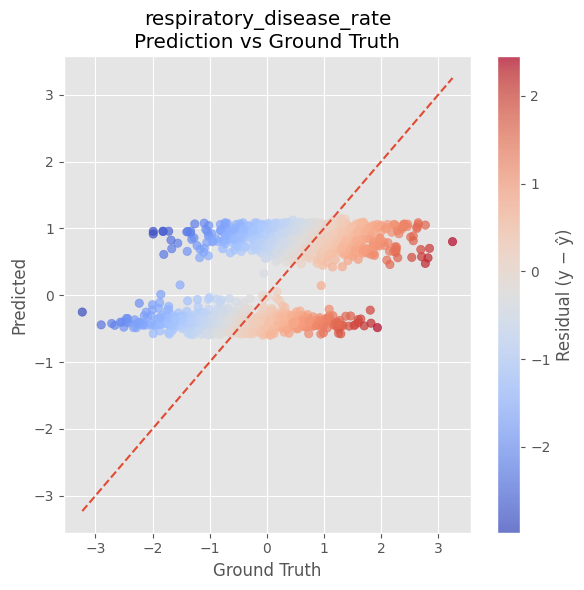

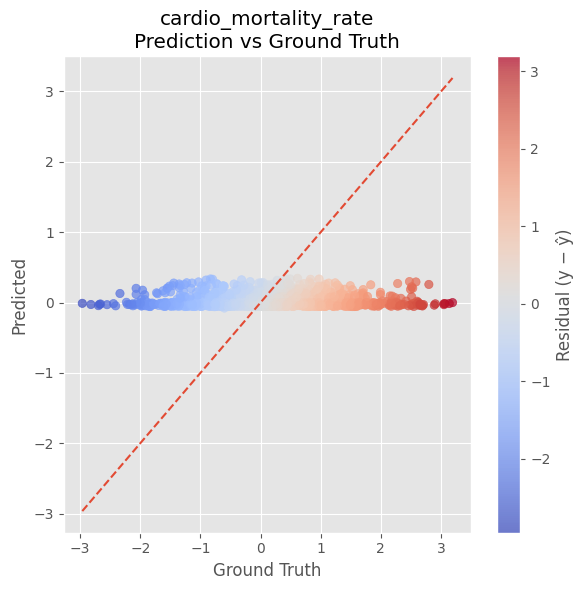

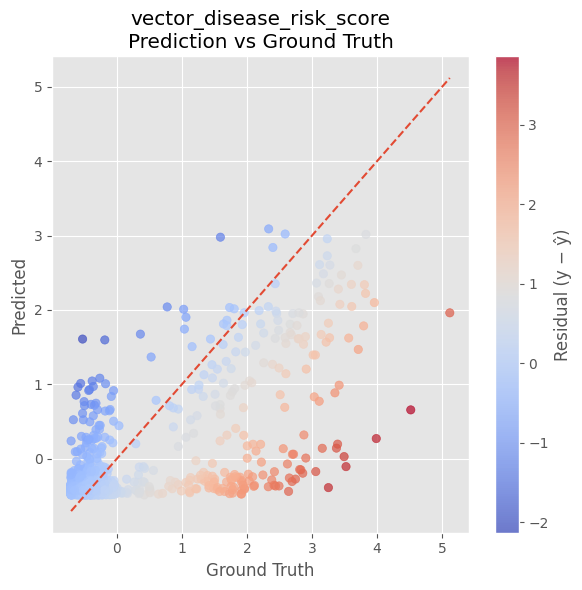

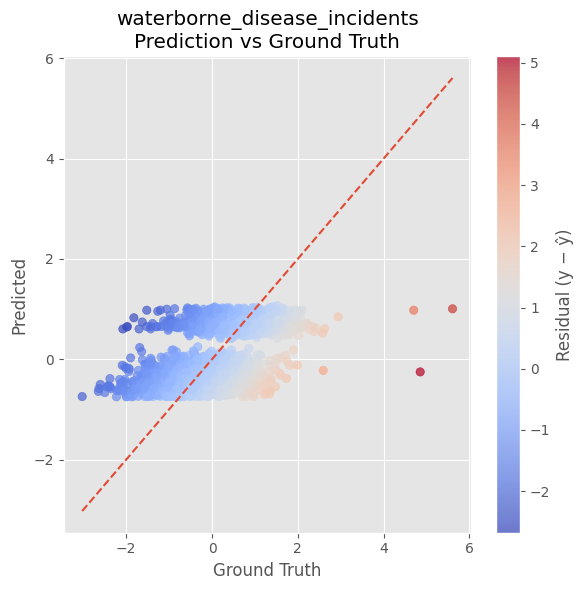

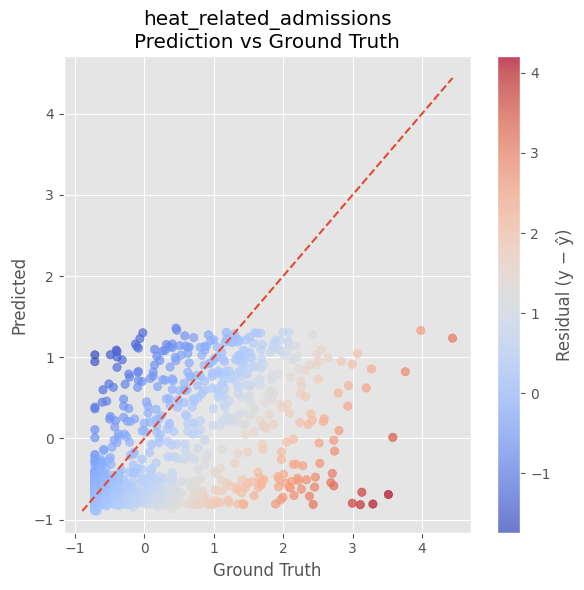

In [280]:
for i, target in enumerate(targets):
    plt.figure(figsize=(6, 6))

    sc = plt.scatter(
        y_true[:, i],
        y_pred[:, i],
        c=residuals[:, i],
        cmap="coolwarm",
        alpha=0.7
    )

    min_val = min(y_true[:, i].min(), y_pred[:, i].min())
    max_val = max(y_true[:, i].max(), y_pred[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Ground Truth")
    plt.ylabel("Predicted")
    plt.title(f"{target}\nPrediction vs Ground Truth")

    plt.colorbar(sc, label="Residual (y − ŷ)")
    plt.tight_layout()
    plt.show()


> *Prediction VS observation scatter plots were used to visually assess model calibration and error dispersion for each health indicator independently. The diagonal line represents perfect prediction.*

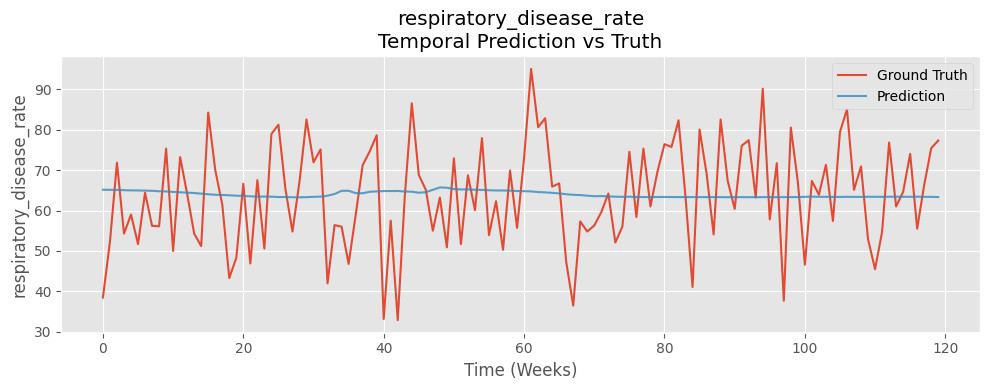

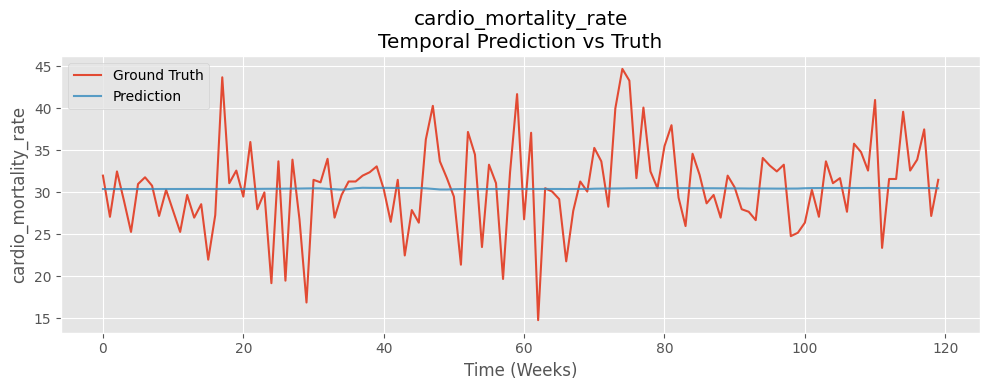

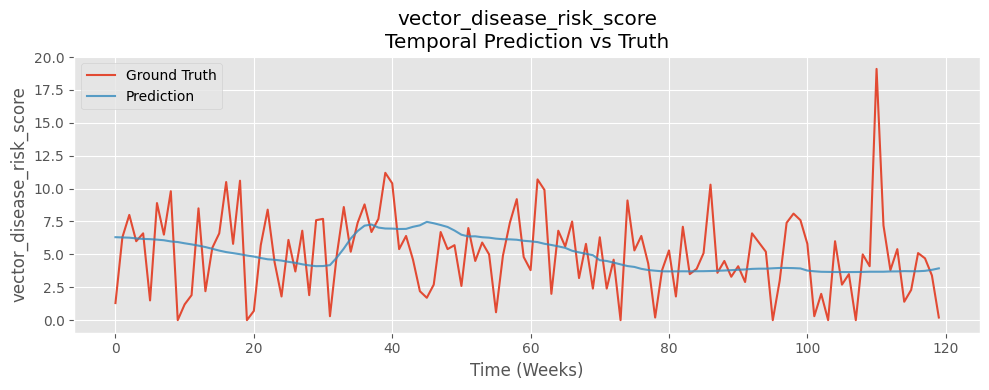

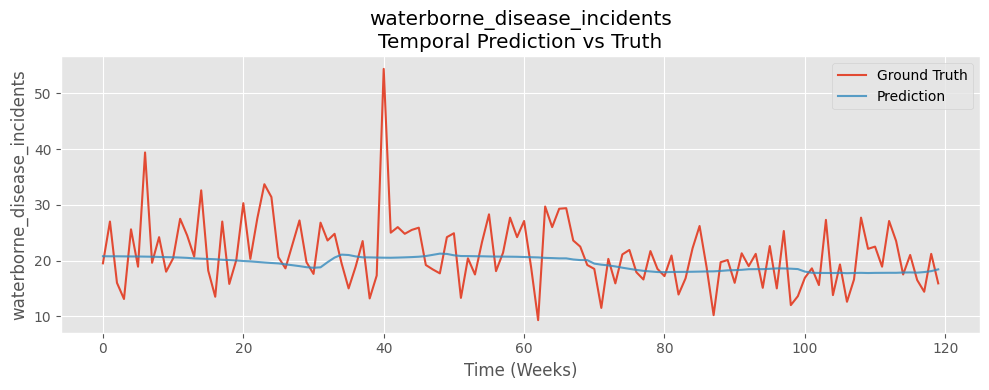

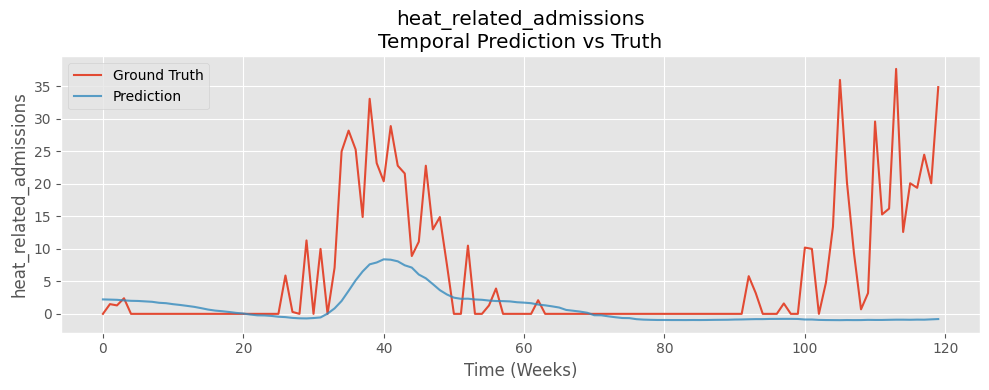

In [274]:
for i, target in enumerate(targets):

    plt.figure(figsize=(10, 4))

    plt.plot(y_true[:120, i], label="Ground Truth")
    plt.plot(y_pred[:120, i], label="Prediction", alpha=0.8)

    plt.xlabel("Time (Weeks)")
    plt.ylabel(target)
    plt.title(f"{target}\nTemporal Prediction vs Truth")
    plt.legend()

    plt.tight_layout()
    plt.show()



> *Residual-based visual diagnostics were used to assess model calibration, temporal consistency, and performance under extreme health events. Error dispersion increased during high-magnitude outcomes, highlighting the intrinsic difficulty of forecasting rare public-health spikes.*



### Inference

# Notes for next mission

## Results

Overall Macro RMSE: 7.377413737059413
| Metric      | Respiratory Disease Rate | Cardio Mortality Rate | Vector Disease Risk Score | Waterborne Disease Incidents | Heat-Related Admissions |
|------------|--------------------------|------------------------|----------------------------|-------------------------------|-------------------------|
| RMSE       | 12.540430               | 5.629658               | 7.391985                   | 5.445827                      | 5.879169                |
| MAE        | 10.031781               | 4.492404               | 4.482436                   | 4.164490                      | 3.671426                |
| R²         | 0.333786                | -0.011049              | 0.820493                   | 0.306793                      | 0.626718                |
| NRMSE (%)  | 12.590793               | 14.324828              | 7.391985                   | 9.076378                      | 11.241242               |

